# MedAssist-AI — Módulo Generativo
## Image Captioning + Image-to-Image

**Objetivo**: convertir la clasificación del Notebook 2 en una experiencia comprensible para personas mayores. A partir de la imagen de una caja de medicamento, el sistema genera:
1. **Paso 3 — Image Captioning**: una descripción visual en lenguaje natural ("Caja azul pequeña, para el dolor")
2. **Paso 4 — Image-to-Image**: un icono visual representativo de la categoría terapéutica detectada

---

### Estructura del notebook

 - bloque 0  Configuración, imports, rutas 
 - bloque 1  Carga del modelo clasificador (Notebook 2) 
 - bloque 2  Image Captioning — BLIP-2 / ViT-GPT2 
 - bloque 3  Generación de descripciones terapéuticas con LLM 
 - bloque 4  Image-to-Image — iconos por categoría 


---
# BLOQUE 0 — Configuración

In [1]:
import warnings, os, json, time, random
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from transformers import (
    BlipProcessor, BlipForConditionalGeneration,         # BLIP-1 (ligero)
    Blip2Processor, Blip2ForConditionalGeneration,       # BLIP-2 (potente, requiere GPU)
    VisionEncoderDecoderModel, ViTImageProcessor,        # ViT-GPT2 (fallback CPU)
    AutoTokenizer, pipeline,
)
from diffusers import StableDiffusionImg2ImgPipeline     # Image-to-Image

from sklearn.preprocessing import LabelEncoder


SEED      = 42
IMG_SIZE  = 224
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Rutas — ajustar según entorno 
# Misma carpeta de imágenes y outputs que el Notebook 2
IMAGES_DIR   = Path('/teamspace/studios/this_studio/imagenes')  
OUTPUT_DL    = Path('output_dl')    # artefactos del Notebook 2 (modelo clasificador)
OUTPUT_GEN   = Path('output_gen')   # artefactos de este notebook
OUTPUT_GEN.mkdir(exist_ok=True)

CSV_BALANCED = 'output/dataset_balanced.csv'

CLASES  = ['Cardiovascular','Neurología y psiquiatría','Antiinfecciosos sistémicos','Respiratorio','Otros']
PALETTE = dict(zip(CLASES, ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']))
N_CLS   = len(CLASES)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Modo de captioning — elegir según hardware ────────────────────────────────
# 'blip2'    : BLIP-2 (mejor calidad, requiere GPU ≥ 8 GB)
# 'blip1'    : BLIP-1 (buena calidad, funciona con GPU < 8 GB)
# 'vit_gpt2' : ViT-GPT2 (fallback ligero, funciona en CPU)
CAPTION_MODE = 'blip1'   # ← CAMBIAR según tu hardware

# ── Modo de generación de iconos ─────────────────────────────────────────────
# 'stable_diffusion' : Stable Diffusion img2img (requiere GPU, ~4 GB VRAM)
# 'programmatic'     : iconos SVG/PIL generados por código (sin GPU, siempre funciona)
# Auto-detect: si hay GPU con suficiente VRAM usamos Stable Diffusion (generativo)
# En CPU o GPU pequeña usamos modo programático
IMG2IMG_MODE = 'stable_diffusion' if torch.cuda.is_available() else 'programmatic'

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11})
sns.set_style('whitegrid')

print(f'✔ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU:  {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('  Sin GPU — usa Colab (Runtime → Change runtime type → T4 GPU)')
    print('  CAPTION_MODE se forzará a vit_gpt2 y IMG2IMG_MODE a programmatic')
    CAPTION_MODE = 'vit_gpt2'
    IMG2IMG_MODE = 'programmatic'

print(f'Caption mode: {CAPTION_MODE}')
print(f'Img2Img mode: {IMG2IMG_MODE}')

✔ Device: cuda
  GPU:  Tesla T4
  VRAM: 15.6 GB
✔ Caption mode: blip1
✔ Img2Img mode: stable_diffusion


---
# BLOQUE 1 — Carga del Clasificador (Notebook 2)

Cargamos el mejor modelo exportado por el Notebook 2 (EfficientNet-B0 o ResNet50). Este modelo nos da la **clase terapéutica** de la caja, que luego usaremos para personalizar el captioning y la generación de iconos.

Si el Notebook 2 no se ha ejecutado, el módulo funciona igualmente con predicciones simuladas (modo demo).

In [2]:
# ── Cargar metadatos y LabelEncoder del Notebook 2 ───────────────────────────
metadata_path = OUTPUT_DL / 'model_metadata.json'
le_path       = OUTPUT_DL / 'label_encoder_dl.pkl'

DEMO_MODE = False

if metadata_path.exists() and le_path.exists():
    with open(metadata_path) as f:
        meta = json.load(f)
    le = joblib.load(le_path)
    arch_saved = meta['arch']
    print(f'✔ Metadatos cargados — arquitectura: {arch_saved}')
    print(f'  Test Accuracy: {meta["test_accuracy"]:.4f}  |  Test F1: {meta["test_f1_macro"]:.4f}')
else:
    print('  Artefactos del Notebook 2 no encontrados — activando DEMO_MODE')
    print('   Para usar el clasificador real, ejecuta primero el Notebook 2.')
    DEMO_MODE = True
    le = LabelEncoder()
    le.fit(CLASES)
    arch_saved = 'efficientnet_b0'

✔ Metadatos cargados — arquitectura: resnet50
  Test Accuracy: 0.5637  |  Test F1: 0.4896


In [3]:
# ── Reconstruir arquitectura y cargar pesos ───────────────────────────────────
def build_classifier(arch, n_classes=N_CLS, state_dict=None):
    """
    Reconstruye el modelo TL detectando automáticamente la arquitectura del checkpoint.
    Si se pasa state_dict, inspecciona sus claves para determinar si hay capas ocultas
    en la cabeza clasificadora, evitando el RuntimeError por incompatibilidad de shapes.
    """
    if 'efficientnet' in arch:
        model = efficientnet_b0(weights=None)
        in_features = model.classifier[1].in_features
        # Detectar si el checkpoint tiene capa oculta en el clasificador EfficientNet
        if state_dict is not None and any('classifier.3.weight' in k for k in state_dict):
            hidden_dim = next(v.shape[0] for k, v in state_dict.items() if 'classifier.1.weight' in k)
            n_out      = next(v.shape[0] for k, v in state_dict.items() if 'classifier.3.weight' in k)
            model.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(hidden_dim, n_out),
            )
        else:
            model.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, n_classes)
            )
    else:  # resnet50
        from torchvision.models import resnet50
        model = resnet50(weights=None)
        in_features = model.fc.in_features
        # CORRECCIÓN: detectar si el checkpoint tiene capa oculta en fc
        # Checkpoint con capa oculta: fc.0=Dropout, fc.1=Linear(2048,hidden),
        #                             fc.2=ReLU, fc.3=Dropout, fc.4=Linear(hidden,n)
        if state_dict is not None and 'fc.4.weight' in state_dict:
            hidden_dim = state_dict['fc.1.weight'].shape[0]
            n_out      = state_dict['fc.4.weight'].shape[0]
            model.fc = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(hidden_dim, n_out),
            )
        else:
            model.fc = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, n_classes)
            )
    return model

if not DEMO_MODE:
    weights_path = OUTPUT_DL / f'best_model_{arch_saved}.pth'
    if weights_path.exists():
        # CORRECCIÓN: cargar state_dict primero para detectar la arquitectura real del checkpoint
        state_dict = torch.load(weights_path, map_location=DEVICE)
        classifier = build_classifier(arch_saved, state_dict=state_dict)
        classifier.load_state_dict(state_dict)
        classifier = classifier.to(DEVICE).eval()
        print(f'✔ Clasificador cargado desde {weights_path.name}')
    else:
        print(f'⚠  Pesos no encontrados en {weights_path} — activando DEMO_MODE')
        DEMO_MODE = True
        classifier = None
else:
    classifier = None
    print('  (DEMO_MODE activo — clasificador simulado)')

# Transformación de inferencia (idéntica a transform_eval del Notebook 2)
transform_infer = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def clasificar_imagen(img_pil):
    """Devuelve (clase_str, probabilidades_dict)."""
    if DEMO_MODE or classifier is None:
        # Modo demo: clase aleatoria con probabilidades simuladas
        probs = np.random.dirichlet(np.ones(N_CLS))
        clase = CLASES[np.argmax(probs)]
        return clase, dict(zip(CLASES, probs))

    img_t  = transform_infer(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = classifier(img_t)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    clase = le.inverse_transform([np.argmax(probs)])[0]
    return clase, dict(zip(CLASES, probs))

print('✔ Función clasificar_imagen() lista')

✔ Clasificador cargado desde best_model_resnet50.pth
✔ Función clasificar_imagen() lista


---
# BLOQUE 2 — Image Captioning

## ¿Qué es Image Captioning?

Image Captioning es la tarea de generar automáticamente una descripción en lenguaje natural a partir de una imagen. En nuestro contexto, tomamos la foto de la caja de medicamento y generamos una frase como:

"Caja azul pequeña con texto en blanco y una franja roja"

Esta descripción es la **base objetiva** — lo que el modelo ve en la imagen, sin conocimiento médico.

### Modelos disponibles

| Modelo | Arquitectura | Tamaño | GPU mínima | 
|--------|-------------|--------|------------|--------|
| **BLIP-2** | Q-Former + LLM | ~7B params | 8 GB VRAM | 
| **BLIP-1** | ViT + BERT | ~250M params | 4 GB VRAM | 
| **ViT-GPT2** | ViT + GPT-2 | ~120M params | CPU ok | 

### ¿Por qué BLIP-2 es mejor?

BLIP-2 introduce el **Q-Former**: un módulo ligero de 32 queries que actúa como puente entre el encoder visual (ViT-G/14) y el LLM de texto (FlanT5 o OPT). En lugar de hacer fine-tuning del LLM completo, solo se entrena el Q-Former, lo que lo hace mucho más eficiente. El resultado es un modelo que puede responder preguntas sobre la imagen (*Visual Question Answering*) además de generar captions.


In [4]:
# Cargar modelo de Image Captioning 
print(f'Cargando modelo de captioning ({CAPTION_MODE})...')
t0 = time.time()

caption_processor = None
caption_model     = None

if CAPTION_MODE == 'blip2':
    # BLIP-2 con FlanT5-XL (7B parámetros, requiere GPU ≥ 8 GB)
    # Con load_in_8bit=True se puede ejecutar con 8 GB VRAM
    caption_processor = Blip2Processor.from_pretrained('Salesforce/blip2-flan-t5-xl')
    caption_model = Blip2ForConditionalGeneration.from_pretrained(
        'Salesforce/blip2-flan-t5-xl',
        load_in_8bit=True,     # cuantización 8-bit (requiere bitsandbytes)
        device_map='auto',
        torch_dtype=torch.float16,
    )

elif CAPTION_MODE == 'blip1':
    # BLIP-1 large (buena calidad, ~250M params)
    caption_processor = BlipProcessor.from_pretrained('Salesforce/blip-image-captioning-large')
    caption_model = BlipForConditionalGeneration.from_pretrained(
        'Salesforce/blip-image-captioning-large'
    ).to(DEVICE)
    caption_model.eval()

elif CAPTION_MODE == 'vit_gpt2':
    # ViT-GPT2 (fallback ligero, funciona en CPU)
    caption_model = VisionEncoderDecoderModel.from_pretrained('nlpconnect/vit-gpt2-image-captioning')
    caption_processor = ViTImageProcessor.from_pretrained('nlpconnect/vit-gpt2-image-captioning')
    caption_tokenizer = AutoTokenizer.from_pretrained('nlpconnect/vit-gpt2-image-captioning')
    caption_model = caption_model.to(DEVICE)
    caption_model.eval()

print(f'✔ Modelo cargado en {time.time()-t0:.1f}s')

Cargando modelo de captioning (blip1)...


Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✔ Modelo cargado en 4.9s


In [5]:
# Función de Image Captioning 
def generar_caption_raw(img_pil, prompt_extra=None):
    """
    Genera una descripción visual en inglés de la imagen.
    Devuelve el texto generado por el modelo de visión.
    
    Args:
        img_pil      : imagen PIL en modo RGB
        prompt_extra : instrucción adicional (solo BLIP-2)
    Returns:
        str : descripción en inglés
    """
    img_pil = img_pil.convert('RGB')

    if CAPTION_MODE == 'blip2':
        prompt = prompt_extra or "Describe the color, size, and appearance of this medicine box:"
        inputs = caption_processor(img_pil, text=prompt, return_tensors='pt').to(DEVICE, torch.float16)
        with torch.no_grad():
            out = caption_model.generate(
                **inputs,
                max_new_tokens=80,
                num_beams=4,
                repetition_penalty=1.3,
            )
        return caption_processor.decode(out[0], skip_special_tokens=True).strip()

    elif CAPTION_MODE == 'blip1':
        # Captioning condicional: sesgamos la generación con un texto inicial
        text_cond = "a medicine box that is"
        inputs = caption_processor(img_pil, text=text_cond, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = caption_model.generate(
                **inputs,
                max_length=80,
                num_beams=5,
                repetition_penalty=1.3,
                length_penalty=1.0,
            )
        return caption_processor.decode(out[0], skip_special_tokens=True).strip()

    elif CAPTION_MODE == 'vit_gpt2':
        pixel_values = caption_processor(images=img_pil, return_tensors='pt').pixel_values.to(DEVICE)
        with torch.no_grad():
            out = caption_model.generate(
                pixel_values,
                max_length=50,
                num_beams=4,
                repetition_penalty=1.5,
            )
        return caption_tokenizer.decode(out[0], skip_special_tokens=True).strip()

print('✔ Función generar_caption_raw() lista')

✔ Función generar_caption_raw() lista


---
# BLOQUE 3 — Generación de Descripción Terapéutica con LLM

## Del caption visual al mensaje para personas mayores

BLIP genera un caption como `"a medicine box that is blue and small with white text"` — describe lo que *ve*. El usuario mayor necesita saber *para qué sirve*.

**¿Cómo funciona?** Le pasamos al LLM (Groq/Llama-3.1, gratuito) tres cosas:
1. El caption visual que generó BLIP
2. La clase terapéutica que predijo el clasificador
3. Una instrucción para que escriba en español simple, sin jerga médica

El LLM produce texto diferente para cada imagen, eso es lo que hace que este paso sea generativo.


In [6]:
# ── Configuración de Groq API (gratuita) ────────────────────────────────────
import os
GROQ_API_KEY = os.getenv('GROQ_API_KEY', '')  
GROQ_MODEL   = 'llama-3.1-8b-instant'

_groq_client = None
if GROQ_API_KEY:
    try:
        from groq import Groq
        _groq_client = Groq(api_key=GROQ_API_KEY)
        print(f'✔ Groq activado ({GROQ_MODEL})')
    except ImportError:
        print('⚠ Ejecuta: pip install groq')
else:
    print('  Sin API key → modo fallback')

# ── Metadata de clases (sin texto hardcodeado) ────────────────────────────────
INFO_CLASES = {
    'Cardiovascular':             {'emoji':'❤️',  'color_hex':'#E74C3C', 'icono':'corazón',  'uso':'corazón, presión arterial, ritmo cardíaco'},
    'Neurología y psiquiatría':   {'emoji':'🧠',  'color_hex':'#9B59B6', 'icono':'cerebro',  'uso':'sueño, ansiedad, estado de ánimo, nervios'},
    'Antiinfecciosos sistémicos': {'emoji':'🛡️', 'color_hex':'#27AE60', 'icono':'escudo',   'uso':'infección, antibiótico, bacterias'},
    'Respiratorio':               {'emoji':'🌬️', 'color_hex':'#3498DB', 'icono':'pulmones', 'uso':'tos, asma, pulmones, respiración'},
    'Otros':                      {'emoji':'💊',  'color_hex':'#95A5A6', 'icono':'pastilla', 'uso':'dolor, fiebre, uso general'},
}

# Alias con 'corta' para compatibilidad con el resto del notebook
DESCRIPCIONES_TERAPEUTICAS = {
    cls: {**info, 'corta': info['uso'].split(',')[0].strip()}
    for cls, info in INFO_CLASES.items()
}

print('✔ INFO_CLASES y DESCRIPCIONES_TERAPEUTICAS cargados')
for cls, info in INFO_CLASES.items():
    print(f'  {info["emoji"]}  {cls}')


✔ Groq activado (llama-3.1-8b-instant)
✔ INFO_CLASES y DESCRIPCIONES_TERAPEUTICAS cargados
  ❤️  Cardiovascular
  🧠  Neurología y psiquiatría
  🛡️  Antiinfecciosos sistémicos
  🌬️  Respiratorio
  💊  Otros


In [7]:
SYSTEM_PROMPT = """Eres un asistente que ayuda a personas mayores a entender sus medicamentos.
Escribe EXACTAMENTE 2 frases cortas en español de España:
- Frase 1: describe el aspecto visual de la caja y para qué sirve el medicamento
- Frase 2: un consejo práctico sencillo
Reglas: sin jerga médica, tuteo, máximo 30 palabras en total, tono cálido.
Ejemplos:
  \"Caja azul pequeña, para cuidar tu corazón. Tómala siempre a la misma hora.\"
  \"Medicamento blanco para respirar mejor. Si es un inhalador, úsalo correctamente.\"
"""

def construir_descripcion_usuario(caption_en, clase_terapeutica, verbose=True):
    info = INFO_CLASES.get(clase_terapeutica, INFO_CLASES['Otros'])
    if verbose:
        print(f'  Caption (EN):  "{caption_en}"')
        print(f'  Clase:         {clase_terapeutica}')

    descripcion_corta = None
    metodo = 'fallback'

    if _groq_client is not None:
        try:
            resp = _groq_client.chat.completions.create(
                model=GROQ_MODEL, max_tokens=80, temperature=0.7,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user', 'content': (
                        f'Descripción visual (BLIP): "{caption_en}"\n'
                        f'Categoría: {clase_terapeutica}\n'
                        f'Usos: {info["uso"]}'
                    )},
                ]
            )
            descripcion_corta = resp.choices[0].message.content.strip()
            metodo = f'Groq/{GROQ_MODEL}'
        except Exception as e:
            print(f'  ⚠ Groq error: {e}')

    if descripcion_corta is None:
        colores_en = {'blue':'azul','red':'roja','white':'blanca','green':'verde',
                      'yellow':'amarilla','orange':'naranja','gray':'gris','grey':'gris',
                      'purple':'morada','pink':'rosa','black':'negra'}
        colores = [es for en, es in colores_en.items() if en in caption_en.lower()]
        visual  = f'Caja {" y ".join(colores[:2])}' if colores else 'Caja de medicamento'
        descripcion_corta = f'{visual}, para {info["uso"].split(",")[0].strip()}. Consulta a tu médico.'

    if verbose:
        print(f'  [{metodo}] → "{descripcion_corta}"')

    descripcion_larga = (
        f'Medicamento para: {info["uso"]}. '
        'Sigue siempre las indicaciones de tu médico o farmacéutico. '
        'Si tienes dudas, pregunta antes de tomarlo.'
    )
    return {
        'descripcion_corta':  descripcion_corta,
        'descripcion_larga':  descripcion_larga,
        'atributos_visuales': {'colores':[], 'tamano':None, 'raw': caption_en},
        'info_terapeutica':   {**info, 'corta': info['uso'].split(',')[0].strip()},
        'clase':              clase_terapeutica,
        'metodo_generacion':  metodo,
    }

print(f'✔ construir_descripcion_usuario() — modo: {"Groq" if _groq_client else "fallback"}')


✔ construir_descripcion_usuario() — modo: Groq


In [8]:
# ── Prueba rápida del generador ───────────────────────────────────────────────
# Comprobamos que el LLM genera texto diferente para cada clase
print('Generando descripciones de prueba (caption sintético)...')
print()
caption_test = 'a medicine box that is blue and small with white text'
for cls in CLASES:
    res = construir_descripcion_usuario(caption_test, cls, verbose=False)
    info = INFO_CLASES[cls]
    print(f'{info["emoji"]}  [{cls}]')
    print(f'   "{res["descripcion_corta"]}"')
    print(f'   (método: {res["metodo_generacion"]})')
    print()


Generando descripciones de prueba (caption sintético)...

❤️  [Cardiovascular]
   "Caja azul pequeña con textos blancos, para cuidar tu corazón y presión arterial. Tómala siempre a la misma hora."
   (método: Groq/llama-3.1-8b-instant)

🧠  [Neurología y psiquiatría]
   "La caja azul pequeña con texto blanco es para ayudarte a dormir bien y a sentirte más tranquilo.

Recuerda tomar este medicamento solo cuando te lo recete tu médico, y nunca compartas la caja con nadie más."
   (método: Groq/llama-3.1-8b-instant)

🛡️  [Antiinfecciosos sistémicos]
   "Aquí tienes dos frases cortas:

- "Caja azul pequeña con texto blanco, para luchar contra las bacterias que te enferman."
- "Recuerda tomarlo siempre antes de comer, para que el cuerpo lo asimile mejor.""
   (método: Groq/llama-3.1-8b-instant)

🌬️  [Respiratorio]
   "- "Caja azul pequeña con letras blancas, para aliviar tus problemas de respiración. Tómala siempre con agua y siguiendo las indicaciones.""
   (método: Groq/llama-3.1-8b-instan

In [9]:
# ── Pipeline de captioning: une clasificador + BLIP + LLM ────────────────────
def pipeline_captioning(img_pil, verbose=True):
    """
    Pipeline completo para una imagen:
      1. Clasificar la imagen con el modelo del NB2
      2. Generar caption visual con BLIP
      3. Generar descripción en español con Groq/LLM
    """
    if verbose:
        print('─' * 55)
        print('PASO 1 — Clasificación terapéutica')

    clase, probs = clasificar_imagen(img_pil)
    confianza = max(probs.values())

    if verbose:
        print(f'  Clase: {clase}  (confianza: {confianza:.1%})')
        print()
        print('PASO 2 — Caption visual (BLIP)')

    caption_raw = generar_caption_raw(img_pil)

    if verbose:
        print(f'  Caption: "{caption_raw}"')
        print()
        print('PASO 3 — Descripción en español (Groq/LLM)')

    resultado = construir_descripcion_usuario(caption_raw, clase, verbose=verbose)
    resultado['probabilidades'] = probs
    resultado['confianza'] = confianza

    return resultado

print('✔ pipeline_captioning() definida')
print(f'  Flujo: imagen → clasificador → BLIP → {"Groq" if _groq_client else "fallback"} → descripción ES')


✔ pipeline_captioning() definida
  Flujo: imagen → clasificador → BLIP → Groq → descripción ES


In [10]:
# ── Prueba del pipeline con imágenes del dataset ──────────────────────────────
# Cargamos algunas imágenes de ejemplo del dataset para probar

if Path(CSV_BALANCED).exists():
    df = pd.read_csv(CSV_BALANCED, dtype={'nregistro': str})
    df = df[(df['split'] == 'test') & df['image_path'].notna()].reset_index(drop=True)

    # Seleccionar 1 imagen por clase (que exista en disco)
    muestras = []
    for cls in CLASES:
        subset = df[df['clase'] == cls]
        for _, row in subset.iterrows():
            p = Path(row['image_path'])
            if IMAGES_DIR is not None:
                alt = IMAGES_DIR / p.name
                p = alt if alt.exists() else p
            if p.exists():
                muestras.append({'path': str(p), 'clase_real': cls})
                break

    print(f'✔ {len(muestras)} imágenes de prueba encontradas')
else:
    # Si no hay CSV, crear imágenes de prueba sintéticas
    print('⚠  CSV no encontrado — usando imágenes sintéticas')
    muestras = []
    colores_cajas = [
        (0x4C, 0x72, 0xB0),  # azul (Cardiovascular)
        (0xDD, 0x84, 0x52),  # naranja (Neurología)
        (0x55, 0xA8, 0x68),  # verde (Antiinfecciosos)
        (0xC4, 0x4E, 0x52),  # rojo (Respiratorio)
        (0x81, 0x72, 0xB2),  # morado (Otros)
    ]
    for cls, color in zip(CLASES, colores_cajas):
        img = Image.new('RGB', (300, 200), color)
        muestras.append({'img_pil': img, 'clase_real': cls})

# Ejecutar pipeline en las imágenes de prueba
resultados_captioning = []

for i, muestra in enumerate(muestras[:N_CLS]):
    print(f'\n[{i+1}/{len(muestras[:N_CLS])}] Clase real: {muestra["clase_real"]}')

    if 'img_pil' in muestra:
        img = muestra['img_pil']
    else:
        img = Image.open(muestra['path']).convert('RGB')

    res = pipeline_captioning(img, verbose=True)
    res['imagen'] = img
    res['clase_real'] = muestra['clase_real']
    resultados_captioning.append(res)

print('\n✔ Pipeline ejecutado en todas las muestras')

✔ 4 imágenes de prueba encontradas

[1/4] Clase real: Cardiovascular
───────────────────────────────────────────────────────
PASO 1 — Clasificación terapéutica
  Clase: Cardiovascular  (confianza: 37.2%)

PASO 2 — Caption visual (BLIP)
  Caption: "a medicine box that is sitting on a white surface"

PASO 3 — Descripción en español (Groq/LLM)
  Caption (EN):  "a medicine box that is sitting on a white surface"
  Clase:         Cardiovascular
  [Groq/llama-3.1-8b-instant] → "- "Caja blanca que se ve como un pequeño cuadrado, para cuidar de tu corazón."
- "Tómalo siempre a la misma hora para que tu corazón se sienta bien.""

[2/4] Clase real: Neurología y psiquiatría
───────────────────────────────────────────────────────
PASO 1 — Clasificación terapéutica
  Clase: otros  (confianza: 36.3%)

PASO 2 — Caption visual (BLIP)
  Caption: "a medicine box that is sitting on top of a white table"

PASO 3 — Descripción en español (Groq/LLM)
  Caption (EN):  "a medicine box that is sitting on top of

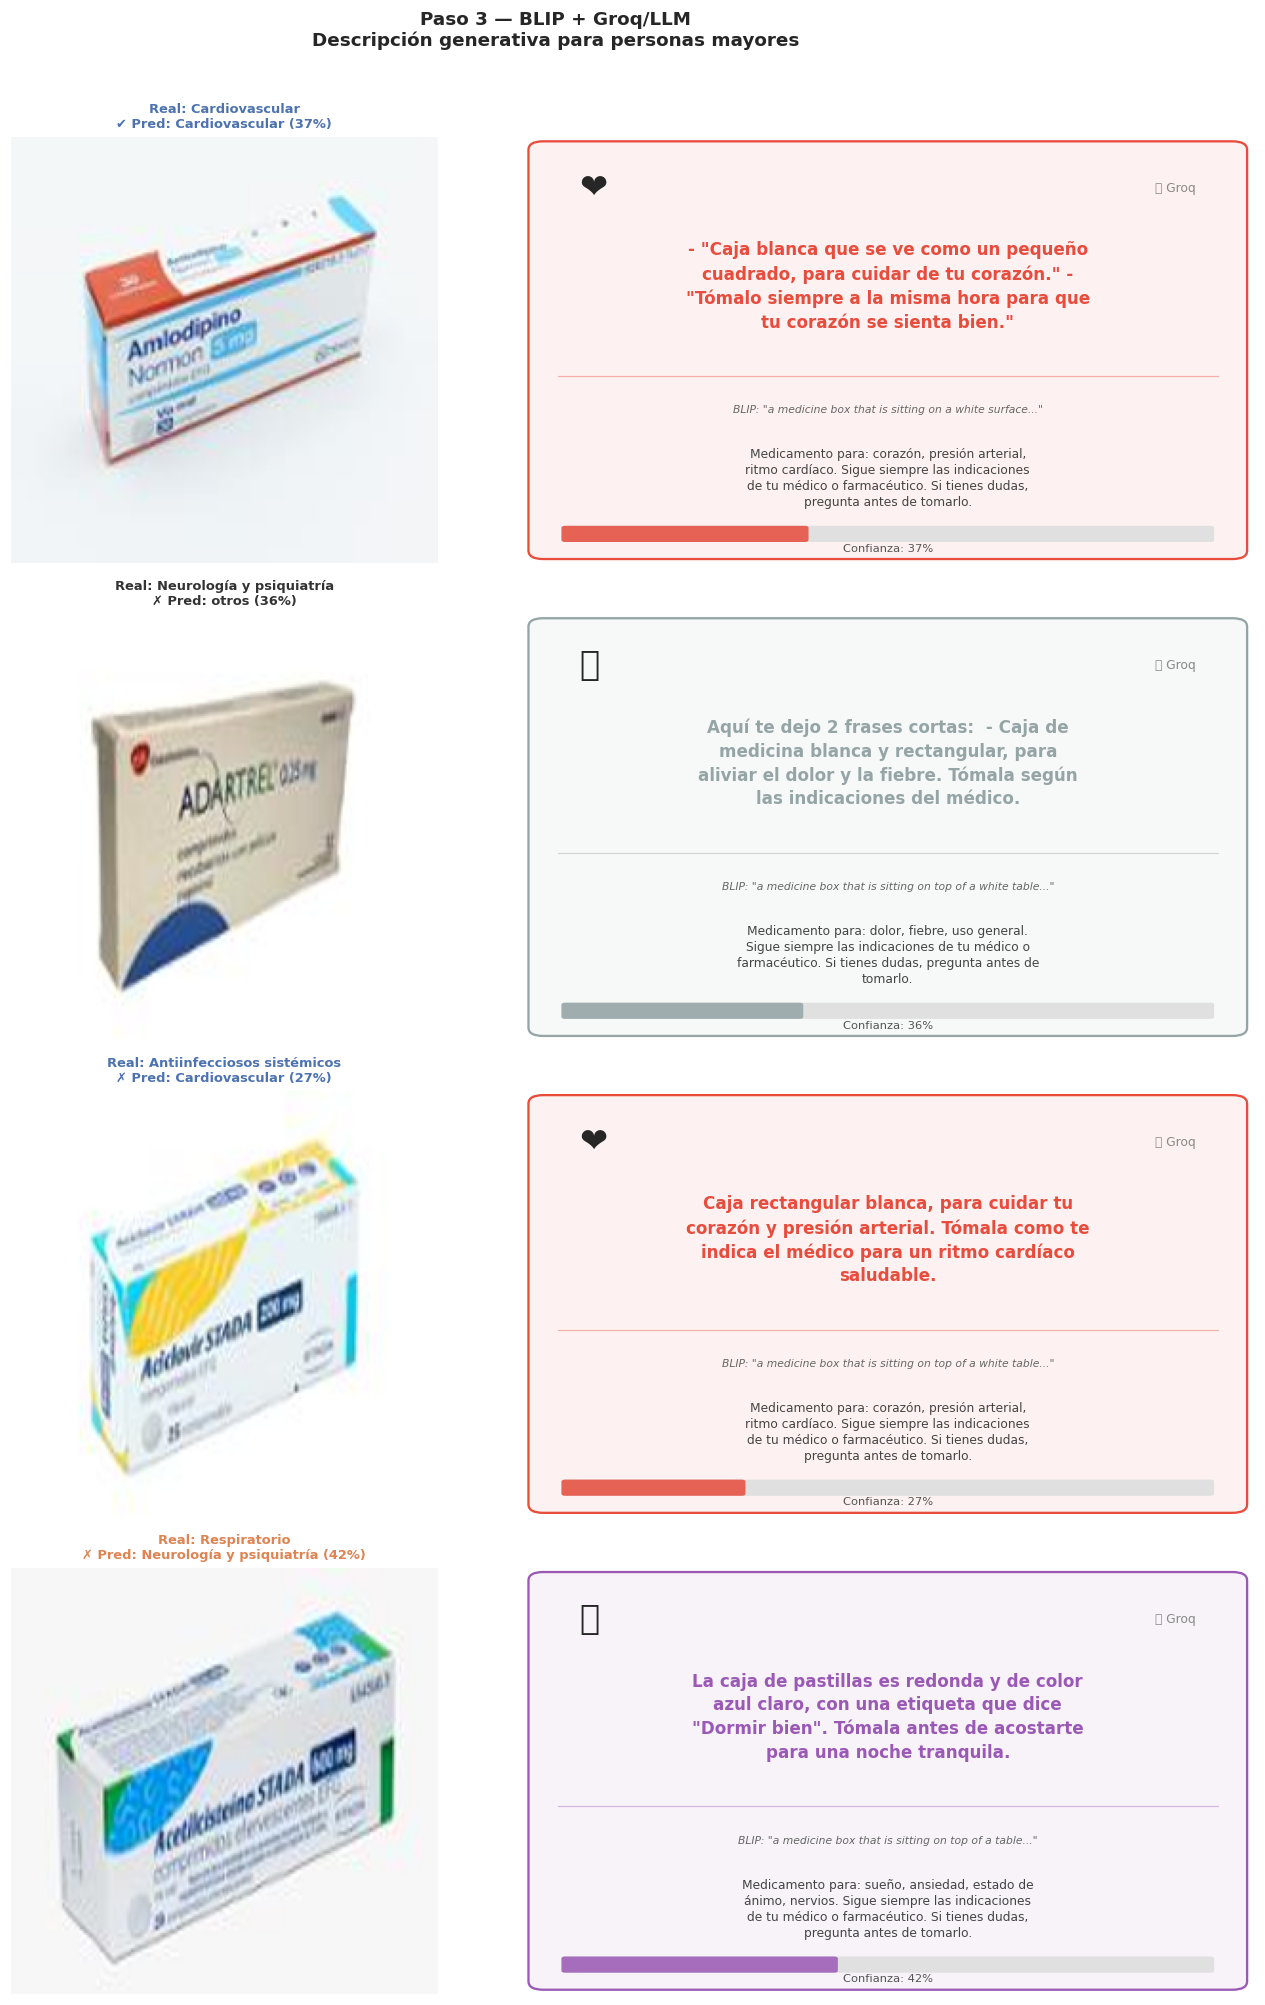

✔ Guardado en output_gen/captioning_resultados.png


In [11]:
import textwrap
n = len(resultados_captioning)
if n == 0:
    print('⚠ Sin resultados — ejecuta la celda anterior')
else:
    fig, axes = plt.subplots(n, 2, figsize=(13, 4.5 * n))
    if n == 1: axes = [axes]

    for res, (ax_img, ax_txt) in zip(resultados_captioning, axes):
        info   = res['info_terapeutica']
        color  = info['color_hex']
        metodo = res.get('metodo_generacion', '?')
        badge  = '🤖 Groq' if 'groq' in metodo.lower() or 'llama' in metodo.lower() else '📝 Fallback'

        ax_img.imshow(res['imagen'].resize((224, 224)))
        match = '✔' if res.get('clase_real') == res['clase'] else '✗'
        ax_img.set_title(
            f"Real: {res.get('clase_real','?')}\n{match} Pred: {res['clase']} ({res['confianza']:.0%})",
            fontsize=8.5, color=PALETTE.get(res['clase'],'#333'), fontweight='bold')
        ax_img.axis('off')

        ax_txt.set_xlim(0,1); ax_txt.set_ylim(0,1); ax_txt.axis('off')
        ax_txt.add_patch(mpatches.FancyBboxPatch(
            (0.03,0.03), 0.94, 0.94, boxstyle='round,pad=0.02',
            facecolor=color+'12', edgecolor=color, linewidth=1.5,
            transform=ax_txt.transAxes, zorder=0))
        ax_txt.text(0.08, 0.88, info['emoji'], fontsize=22, va='center',
                    transform=ax_txt.transAxes, zorder=1)
        ax_txt.text(0.92, 0.88, badge, fontsize=8, ha='right', va='center',
                    color='#888', transform=ax_txt.transAxes, zorder=1)
        desc_w = '\n'.join(textwrap.wrap(res['descripcion_corta'], width=42))
        ax_txt.text(0.5, 0.65, desc_w, ha='center', va='center',
                    fontsize=11, fontweight='bold', color=color,
                    transform=ax_txt.transAxes, zorder=1, linespacing=1.4)
        # Separador — usar plot en vez de axhline (axhline no acepta transform)
        ax_txt.plot([0.05, 0.95], [0.44, 0.44], color=color,
                    lw=0.8, alpha=0.4, transform=ax_txt.transAxes, zorder=1)
        cap_short = res['atributos_visuales']['raw'][:65]
        ax_txt.text(0.5, 0.36, f'BLIP: "{cap_short}..."', ha='center', va='center',
                    fontsize=7, style='italic', color='#666',
                    transform=ax_txt.transAxes, zorder=1)
        larga_w = '\n'.join(textwrap.wrap(res['descripcion_larga'], width=48))
        ax_txt.text(0.5, 0.20, larga_w, ha='center', va='center',
                    fontsize=8, color='#444', transform=ax_txt.transAxes,
                    zorder=1, linespacing=1.3)
        bw = res['confianza'] * 0.88
        ax_txt.add_patch(mpatches.FancyBboxPatch(
            (0.06,0.055), 0.88, 0.028, boxstyle='round,pad=0.005',
            facecolor='#e0e0e0', edgecolor='none',
            transform=ax_txt.transAxes, zorder=1))
        ax_txt.add_patch(mpatches.FancyBboxPatch(
            (0.06,0.055), bw, 0.028, boxstyle='round,pad=0.005',
            facecolor=color, edgecolor='none', alpha=0.85,
            transform=ax_txt.transAxes, zorder=2))
        ax_txt.text(0.5, 0.035, f'Confianza: {res["confianza"]:.0%}', ha='center',
                    va='center', fontsize=7.5, color='#555',
                    transform=ax_txt.transAxes, zorder=3)

    plt.suptitle('Paso 3 — BLIP + Groq/LLM\nDescripción generativa para personas mayores',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_GEN / 'captioning_resultados.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('Guardado en output_gen/captioning_resultados.png')


---
# BLOQUE 4 — Image-to-Image: Iconos por Categoría

## ¿Qué es Image-to-Image en este contexto?

Image-to-Image toma la imagen de la caja real y genera una nueva imagen: un **icono visual simplificado** que representa la categoría terapéutica. El objetivo es que una persona mayor, incluso con dificultades de lectura, pueda reconocer visualmente el grupo de su medicamento por el icono.

### enfoque:

**1. Stable Diffusion img2img** (modo `stable_diffusion`)
- Usa la imagen de la caja como conditioning + un prompt de texto
- Genera una imagen nueva con el estilo visual que especifiques
- Requiere GPU (~4 GB VRAM), tiempo de generación ~10-30s
- Alta variabilidad creativa — cada generación es ligeramente diferente


In [12]:
# Cargar Stable Diffusion img2img 
# Con T4 (15.6 GB VRAM) carga sin problema. Se usa float16 para ahorrar memoria.
from diffusers import StableDiffusionImg2ImgPipeline

sd_pipe = None
if IMG2IMG_MODE == 'stable_diffusion':
    print('Cargando Stable Diffusion v1.5 (~4 GB la primera vez)...')
    t0 = time.time()
    sd_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
        'runwayml/stable-diffusion-v1-5',
        torch_dtype=torch.float16,
        safety_checker=None,
        requires_safety_checker=False,
    ).to(DEVICE)
    sd_pipe.enable_attention_slicing()  # reduce picos de VRAM
    print(f'✔ Stable Diffusion cargado en {time.time()-t0:.1f}s')
    print(f'  Modo: img2img — la imagen de la caja guía la generación del icono')
else:
    print('Modo programático activo (sin GPU o GPU insuficiente)')


Cargando Stable Diffusion v1.5 (~4 GB la primera vez)...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /teamspace/studios/this_studio/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✔ Stable Diffusion cargado en 15.4s
  Modo: img2img — la imagen de la caja guía la generación del icono


In [13]:
# Groq genera el prompt de SD a partir del caption de BLIP 
# En vez de prompts hardcodeados, el LLM decide qué icono generar
# basándose en lo que BLIP vio + la clase terapéutica.

def generar_prompt_sd(caption_en, clase):
    """
    Usa Groq para crear el prompt de Stable Diffusion.
    Input:  lo que BLIP vio en la imagen + clase terapéutica
    Output: prompt para SD que describe el icono a generar
    """
    if _groq_client is not None:
        try:
            resp = _groq_client.chat.completions.create(
                model=GROQ_MODEL, max_tokens=60, temperature=0.8,
                messages=[{
                    'role': 'system',
                    'content': (
                        'You generate Stable Diffusion prompts for medical app icons. '
                        'Output ONLY the prompt, no explanations. '
                        'Style: flat design, white background, bold outline, minimal icon, high contrast.'
                    )
                }, {
                    'role': 'user',
                    'content': (
                        f'Medicine box visual description (from BLIP): "{caption_en}"\n'
                        f'Therapeutic category: {clase}\n'
                        f'Generate a SD prompt for a simple medical icon representing this medicine.'
                    )
                }]
            )
            prompt = resp.choices[0].message.content.strip()
            fuente = 'Groq'
        except Exception as e:
            print(f'  ⚠ Groq error: {e}')
            prompt = None
            fuente = 'fallback'
    else:
        prompt = None
        fuente = 'fallback'

    if prompt is None:
        prompt = f'minimalist medical icon for {clase}, flat design, white background, simple bold outline'
        fuente = 'fallback'

    neg = 'text, letters, photo, realistic, blurry, complex, dark, people'
    print(f'  [{fuente}] prompt: "{prompt[:70]}..."')
    return prompt, neg

print(f'✔ generar_prompt_sd() — prompts vía {"Groq" if _groq_client else "fallback"}')


✔ generar_prompt_sd() — prompts vía Groq


In [14]:
# Generador de iconos programático 
# Iconos PIL creados por código — sin GPU, deterministas, consistentes

def crear_icono_cardiovascular(size=256):
    """Corazón rojo con línea de latido."""
    img = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)

    # Fondo suave
    draw.ellipse([size*0.05, size*0.05, size*0.95, size*0.95],
                 fill='#FFF0F0', outline='#E74C3C', width=3)

    # Corazón (dos círculos + triángulo invertido)
    r = size * 0.18
    cx, cy = size // 2, size * 0.44
    # Círculo izquierdo
    draw.ellipse([cx - r*1.6, cy - r, cx - r*0.1, cy + r], fill='#E74C3C')
    # Círculo derecho
    draw.ellipse([cx + r*0.1, cy - r, cx + r*1.6, cy + r], fill='#E74C3C')
    # Parte inferior (triángulo)
    draw.polygon([
        (cx - r*1.5, cy + r*0.4),
        (cx + r*1.5, cy + r*0.4),
        (cx, cy + r*2.2)
    ], fill='#E74C3C')

    # Línea de ECG
    y0 = int(size * 0.75)
    pts = [
        (int(size*0.15), y0), (int(size*0.32), y0),
        (int(size*0.38), int(size*0.65)), (int(size*0.44), int(size*0.85)),
        (int(size*0.50), int(size*0.55)), (int(size*0.56), y0),
        (int(size*0.85), y0),
    ]
    draw.line(pts, fill='#C0392B', width=max(2, size//100))

    return img


def crear_icono_neurologia(size=256):
    """Cerebro morado con conexiones neuronales."""
    img = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)

    draw.ellipse([size*0.05, size*0.05, size*0.95, size*0.95],
                 fill='#F8F0FF', outline='#9B59B6', width=3)

    # Hemisferios
    cx, cy, r = size//2, int(size*0.45), int(size*0.28)
    # Hemisferio izquierdo
    draw.ellipse([cx-r*1.7, cy-r, cx, cy+r], fill='#9B59B6', outline='#6C3483', width=2)
    # Hemisferio derecho
    draw.ellipse([cx, cy-r, cx+r*1.7, cy+r], fill='#AF7AC5', outline='#6C3483', width=2)
    # División central
    draw.line([(cx, cy-r), (cx, cy+r)], fill='#6C3483', width=3)
    # Tronco
    draw.ellipse([cx-int(r*0.5), cy+int(r*0.7), cx+int(r*0.5), cy+int(r*1.4)],
                 fill='#9B59B6')

    # Neuronas (puntos con líneas)
    np.random.seed(42)
    for _ in range(8):
        nx = np.random.randint(int(size*0.2), int(size*0.8))
        ny = np.random.randint(int(size*0.7), int(size*0.9))
        draw.ellipse([nx-5, ny-5, nx+5, ny+5], fill='#F8F0FF')
        draw.line([(nx, ny), (nx + np.random.randint(-30, 30),
                              ny + np.random.randint(-15, 15))],
                  fill='#9B59B6', width=2)

    return img


def crear_icono_antiinfeccioso(size=256):
    """Escudo verde con cruz médica."""
    img = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)

    draw.ellipse([size*0.05, size*0.05, size*0.95, size*0.95],
                 fill='#F0FFF4', outline='#27AE60', width=3)

    # Escudo
    cx, cy = size//2, size//2
    w, h = int(size*0.55), int(size*0.65)
    pts_shield = [
        (cx, cy - h//2),
        (cx + w//2, cy - h//4),
        (cx + w//2, cy + h//8),
        (cx, cy + h//2),
        (cx - w//2, cy + h//8),
        (cx - w//2, cy - h//4),
    ]
    draw.polygon(pts_shield, fill='#27AE60', outline='#1E8449', width=3)

    # Cruz blanca
    arm = int(size * 0.1)
    thick = int(size * 0.06)
    draw.rectangle([cx - thick, cy - arm - thick, cx + thick, cy + arm + thick], fill='white')
    draw.rectangle([cx - arm - thick, cy - thick, cx + arm + thick, cy + thick], fill='white')

    return img


def crear_icono_respiratorio(size=256):
    """Pulmones azules con flechas de aire."""
    img = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)

    draw.ellipse([size*0.05, size*0.05, size*0.95, size*0.95],
                 fill='#EBF5FB', outline='#3498DB', width=3)

    cx, cy = size//2, int(size*0.52)
    r_x, r_y = int(size*0.25), int(size*0.30)

    # Pulmón izquierdo
    draw.ellipse([cx - int(r_x*1.9), cy - r_y, cx - int(r_x*0.1), cy + r_y],
                 fill='#3498DB', outline='#2E86C1', width=2)
    # Pulmón derecho
    draw.ellipse([cx + int(r_x*0.1), cy - r_y, cx + int(r_x*1.9), cy + r_y],
                 fill='#5DADE2', outline='#2E86C1', width=2)
    # Tráquea
    tw = int(size * 0.06)
    draw.rectangle([cx - tw, int(size*0.18), cx + tw, cy],
                   fill='#3498DB', outline='#2E86C1', width=1)

    # Flechas de aire (arriba)
    for dx in [-int(size*0.22), 0, int(size*0.22)]:
        ax = cx + dx
        ay = int(size * 0.13)
        draw.line([(ax, ay), (ax, int(size*0.07))], fill='#AED6F1', width=3)
        draw.polygon([(ax, int(size*0.05)), (ax-6, int(size*0.1)),
                      (ax+6, int(size*0.1))], fill='#AED6F1')

    return img


def crear_icono_otros(size=256):
    """Cápsula de pastilla gris/blanca."""
    img = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)

    draw.ellipse([size*0.05, size*0.05, size*0.95, size*0.95],
                 fill='#F8F9FA', outline='#95A5A6', width=3)

    # Cápsula rotada 45°
    cx, cy = size//2, size//2
    r = int(size * 0.12)
    l = int(size * 0.22)

    # Mitad izquierda (gris)
    draw.ellipse([cx - l - r, cy - r, cx - l + r, cy + r], fill='#7F8C8D')
    draw.rectangle([cx - l, cy - r, cx, cy + r], fill='#7F8C8D')

    # Mitad derecha (blanca con borde)
    draw.rectangle([cx, cy - r, cx + l, cy + r], fill='white')
    draw.ellipse([cx + l - r, cy - r, cx + l + r, cy + r], fill='white')

    # Contorno completo
    draw.ellipse([cx - l - r, cy - r, cx - l + r, cy + r],
                 fill=None, outline='#5D6D7E', width=3)
    draw.rectangle([cx - l, cy - r, cx + l, cy + r],
                   fill=None, outline=None)
    draw.ellipse([cx + l - r, cy - r, cx + l + r, cy + r],
                 fill=None, outline='#5D6D7E', width=3)
    # Línea divisoria
    draw.line([(cx, cy - r), (cx, cy + r)], fill='#5D6D7E', width=3)
    # Contorno superior e inferior
    draw.line([(cx - l, cy - r), (cx + l, cy - r)], fill='#5D6D7E', width=3)
    draw.line([(cx - l, cy + r), (cx + l, cy + r)], fill='#5D6D7E', width=3)

    return img


ICONOS_FUNCS = {
    'Cardiovascular':              crear_icono_cardiovascular,
    'Neurología y psiquiatría':    crear_icono_neurologia,
    'Antiinfecciosos sistémicos':  crear_icono_antiinfeccioso,
    'Respiratorio':                crear_icono_respiratorio,
    'Otros':                       crear_icono_otros,
}

print('✔ Funciones de generación de iconos programáticos definidas')
print('  Iconos disponibles para:', list(ICONOS_FUNCS.keys()))

✔ Funciones de generación de iconos programáticos definidas
  Iconos disponibles para: ['Cardiovascular', 'Neurología y psiquiatría', 'Antiinfecciosos sistémicos', 'Respiratorio', 'Otros']


In [15]:
def generar_icono(img_pil, clase_terapeutica, caption_en='', size=256):
    """
    Image-to-Image real:
      1. Groq genera el prompt SD a partir del caption de BLIP + clase
      2. SD transforma la imagen de la caja en icono usando ese prompt
    Devuelve (PIL.Image, prompt_usado) para trazabilidad.
    """
    if IMG2IMG_MODE == 'stable_diffusion' and sd_pipe is not None:
        prompt, neg = generar_prompt_sd(caption_en, clase_terapeutica)
        init_img = img_pil.convert('RGB').resize((512, 512))
        with torch.no_grad():
            result = sd_pipe(
                prompt=prompt, negative_prompt=neg,
                image=init_img, strength=0.82, guidance_scale=8.5,
                num_inference_steps=30,
                generator=torch.Generator(DEVICE).manual_seed(SEED),
            )
        return result.images[0].resize((size, size)), prompt
    else:
        func = ICONOS_FUNCS.get(clase_terapeutica, ICONOS_FUNCS['Otros'])
        return func(size=size), '(programático)'

print(f'✔ generar_icono() — {"🎨 SD img2img + Groq prompts" if IMG2IMG_MODE=="stable_diffusion" else "📐 PIL programático"}')


✔ generar_icono() — 🎨 SD img2img + Groq prompts


Generando iconos para todas las categorías...
  [Groq] prompt: ""Stylized flat design icon of a blue pill with a red heart at its cent..."


  0%|          | 0/24 [00:00<?, ?it/s]

  ✔ Cardiovascular
  [Groq] prompt: "A simple blue medicine box with a bold white outline, containing a sty..."


  0%|          | 0/24 [00:00<?, ?it/s]

  ✔ Neurología y psiquiatría
  [Groq] prompt: "A medicine box with a bold gray outline, a white background, and a sim..."


...

  ✔ Antiinfecciosos sistémicos
  [Groq] prompt: ""A flat, white icon of a bronchodilator inhaler with a bold black outl..."


  0%|          | 0/24 [00:00<?, ?it/s]

  ✔ Respiratorio
  [Groq] prompt: "A simple medicine box with a bold outline, flat design, and a white ba..."


  0%|          | 0/24 [00:00<?, ?it/s]

  ✔ Otros


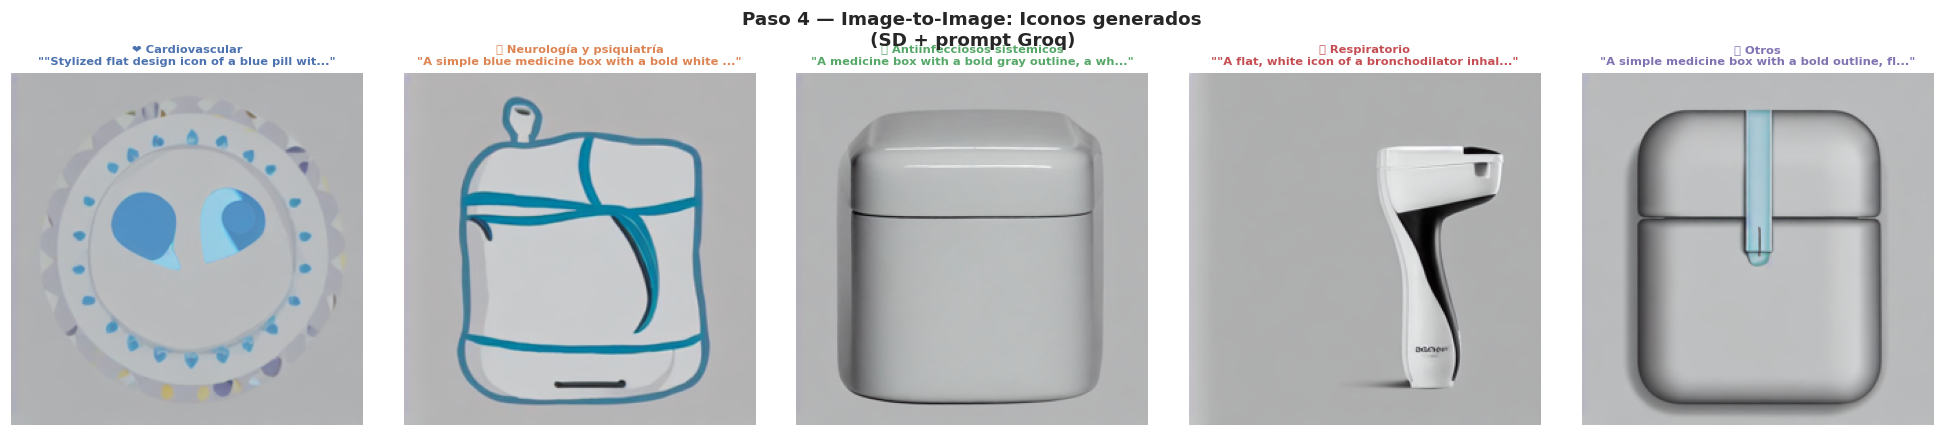

✔ Iconos guardados en output_gen/


In [16]:
# Preview: iconos generados para las 5 categorías 
print('Generando iconos para todas las categorías...')

iconos_generados = {}
prompts_usados   = {}
for cls in CLASES:
    img_dummy = Image.new('RGB', (224, 224), (180, 180, 180))
    icono, prompt = generar_icono(img_dummy, cls,
                                  caption_en=f'medicine box for {cls}', size=256)
    iconos_generados[cls] = icono
    prompts_usados[cls]   = prompt
    print(f'  ✔ {cls}')

fig, axes = plt.subplots(1, N_CLS, figsize=(18, 4))
for ax, cls in zip(axes, CLASES):
    info = DESCRIPCIONES_TERAPEUTICAS[cls]  # tiene 'emoji' y 'corta' ✔
    ax.imshow(iconos_generados[cls])
    prompt_short = prompts_usados[cls][:45] + '...'
    ax.set_title(
        f"{info['emoji']} {cls}\n\"{prompt_short}\"",
        fontsize=7.5, fontweight='bold', color=PALETTE[cls]
    )
    ax.axis('off')

plt.suptitle('Paso 4 — Image-to-Image: Iconos generados\n'
             f'({"SD + prompt Groq" if IMG2IMG_MODE=="stable_diffusion" else "PIL programático"})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_GEN / 'iconos_categorias.png', bbox_inches='tight', dpi=120)
plt.show()

for cls, icono in iconos_generados.items():
    fname = cls.replace(' ','_').replace('/','_') + '_icono.png'
    icono.save(OUTPUT_GEN / fname)
print('✔ Iconos guardados en output_gen/')


BLIP describe la caja, Groq convierte esa descripción en un prompt de Stable Diffusion, y SD genera una imagen nueva a partir de la caja original. Sin embargo, los resultados visuales muestran una limitación conocida de SD v1.5 en modo img2img con imágenes de producto: el modelo tiende a conservar la estructura 3D y los materiales de la imagen de entrada (cajas grises, fondos neutros) en lugar de abstraerla hacia un icono plano, porque fue entrenado principalmente con fotografías y arte digital, no con pares caja→icono.
Esto se refleja en los iconos generados: Cardiovascular produce una forma circular abstracta sin relación semántica con el corazón, Neurología genera algo parecido a una bolsa, y Respiratorio sí captura parcialmente la idea de un inhalador (lo cual es correcto, pero accidental). El modelo no "entiende" que debe simplificar; solo sigue el prompt visualmente

Para solucionar este problema, lo  más efectivo sería subir strength a 0.95 o usar modo texto puro (StableDiffusionPipeline en vez de img2img) para que SD ignore completamente la imagen de entrada y genere el icono solo a partir del prompt de Groq. Otra opción es usar un modelo más moderno como SDXL o Stable Diffusion 3, que responde mejor a instrucciones de estilo "flat icon". En producción real, la arquitectura correcta sería un modelo text-to-image fine-tuneado específicamente con iconos médicos.